# APS Failure — benchmark (custo FP=10, FN=500)

Execute as células em ordem (**Run All**). Coloque o *kernel* com diretório de trabalho na **raiz do projeto** (pasta onde estão os CSV), ou deixe o notebook em `notebooks/` — o código detecta os CSV automaticamente.

**Dependências:** `pip install -r requirements.txt`

In [29]:
# Opcional: instalar dependências (descomente se precisar)
# %pip install -q pandas numpy scikit-learn xgboost matplotlib

In [30]:
%matplotlib inline

import json
import os
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "aps_failure_training_set.csv").exists():
        return cwd
    parent = cwd.parent
    if (parent / "aps_failure_training_set.csv").exists():
        return parent
    raise FileNotFoundError(
        "Não encontrei aps_failure_training_set.csv. Abra o projeto na raiz ou execute o kernel a partir dela."
    )


ROOT = resolve_project_root()
TRAIN_CSV = ROOT / "aps_failure_training_set.csv"
TEST_CSV = ROOT / "aps_failure_test_set.csv"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import APSConfig, with_fast_debug, to_log_dict
from src.experiments import append_experiment_row, grid_search_xgboost_validation, new_run_id

FAST_DEBUG = False  # True: usa with_fast_debug() (treino mais rápido)
cfg = with_fast_debug() if FAST_DEBUG else APSConfig()
RANDOM_STATE = cfg.random_state
FP_COST = cfg.fp_cost
FN_COST = cfg.fn_cost
np.random.seed(RANDOM_STATE)
os.environ.setdefault("PYTHONHASHSEED", str(RANDOM_STATE))
print("ROOT =", ROOT)
print("FAST_DEBUG =", FAST_DEBUG)

ROOT = C:\Projetos Programação\Cursor\deep_learning_atividade_01 - Copia - Copia
FAST_DEBUG = False


## 1. Dados e pré-processamento

In [31]:
def load_raw(training_path: Path, test_path: Path):
    train = pd.read_csv(training_path, na_values=["na"])
    test = pd.read_csv(test_path, na_values=["na"])
    return train, test


def encode_target(train: pd.DataFrame, test: pd.DataFrame):
    label_map = {"neg": 0, "pos": 1}
    y_train = train["class"].map(label_map).to_numpy()
    y_test = test["class"].map(label_map).to_numpy()
    X_train = train.drop(columns=["class"])
    X_test = test.drop(columns=["class"])
    return X_train, X_test, y_train.astype(np.int64), y_test.astype(np.int64)


def drop_degenerate_columns(X_train: pd.DataFrame, X_test: pd.DataFrame):
    all_nan = X_train.columns[X_train.isna().all()].tolist()
    nunique = X_train.nunique(dropna=True)
    constant = nunique[nunique <= 1].index.tolist()
    drop_cols = sorted(set(all_nan + constant))
    if drop_cols:
        X_train = X_train.drop(columns=drop_cols)
        X_test = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns], errors="ignore")
    return X_train, X_test


def fit_imputer(X_train: pd.DataFrame) -> SimpleImputer:
    imputer = SimpleImputer(strategy="median")
    imputer.fit(X_train.to_numpy())
    return imputer


def transform_imputer(imputer: SimpleImputer, X: pd.DataFrame, columns: list[str]) -> np.ndarray:
    return imputer.transform(X[columns].to_numpy())

In [32]:
raw_tr, raw_te = load_raw(TRAIN_CSV, TEST_CSV)
X_tr_df, X_te_df, y_train, y_test = encode_target(raw_tr, raw_te)
X_tr_df, X_te_df = drop_degenerate_columns(X_tr_df, X_te_df)
feature_cols = list(X_tr_df.columns)

imputer = fit_imputer(X_tr_df)
X_imp_train = transform_imputer(imputer, X_tr_df, feature_cols)
X_imp_test = transform_imputer(imputer, X_te_df, feature_cols)

idx = np.arange(len(y_train))
tr_idx, val_idx = train_test_split(
    idx, test_size=cfg.validation_size, stratify=y_train, random_state=RANDOM_STATE
)
X_tr = X_imp_train[tr_idx]
X_val = X_imp_train[val_idx]
y_tr = y_train[tr_idx]
y_val = y_train[val_idx]

print("Treino:", X_imp_train.shape, "| Val interno:", X_val.shape, "| Teste:", X_imp_test.shape)
print("Positivos treino:", int(y_train.sum()), "| teste:", int(y_test.sum()))

Treino: (60000, 169) | Val interno: (12000, 169) | Teste: (16000, 169)
Positivos treino: 1000 | teste: 375


## 2. Métricas e custo

**Legenda das colunas das tabelas de métricas**

- `model`: nome do classificador
- `threshold`: limiar em P(classe positiva); predição = 1 se a probabilidade for ≥ ao limiar
- `accuracy`: fração de exemplos classificados corretamente
- `precision`: entre os preditos como positivos, fração que é realmente positivo (TP / (TP+FP))
- `recall`: entre os positivos reais, fração encontrada pelo modelo (TP / (TP+FN))
- `f1`: média harmônica de precision e recall
- `roc_auc`: área sob a curva ROC (discriminação entre classes)
- `pr_auc`: área sob a curva precision-recall (útil com classes desbalanceadas)
- `cost`: custo total **FP×10 + FN×500** (conforme `cfg`)
- **`true_negatives`**: contagem TN — real **negativo (0)**, predito **0**
- **`false_positives`**: contagem FP — real **negativo (0)**, predito **1** (alarme falso)
- **`false_negatives`**: contagem FN — real **positivo (1)**, predito **0** (falha não detectada)
- **`true_positives`**: contagem TP — real **positivo (1)**, predito **1**

*(Antes eram `cm_tn`, `cm_fp`, `cm_fn`, `cm_tp`; os nomes atuais deixam isso explícito.)*

In [33]:
def total_cost(y_true: np.ndarray, y_pred: np.ndarray, fp_cost=FP_COST, fn_cost=FN_COST) -> float:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp_cost * fp + fn_cost * fn


def confusion_counts(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, int]:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


def classification_metrics(y_true, y_pred, y_proba=None):
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    if y_proba is not None and len(np.unique(y_true)) > 1:
        out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        out["pr_auc"] = float(average_precision_score(y_true, y_proba))
    else:
        out["roc_auc"] = float("nan")
        out["pr_auc"] = float("nan")
    return out


def find_best_threshold(y_true, y_proba, fp_cost=FP_COST, fn_cost=FN_COST, n_thresholds=501):
    y_proba = np.asarray(y_proba, dtype=np.float64).ravel()
    y_true = np.asarray(y_true).ravel()
    candidates = np.unique(
        np.concatenate(
            [
                np.linspace(0.0, 1.0, n_thresholds),
                np.quantile(y_proba, np.linspace(0, 1, min(101, len(y_proba)))),
            ]
        )
    )
    best_t, best_c = 0.5, float("inf")
    for t in candidates:
        y_pred = (y_proba >= t).astype(np.int8)
        c = total_cost(y_true, y_pred, fp_cost, fn_cost)
        if c < best_c:
            best_c, best_t = c, float(t)
    return best_t, best_c


def evaluate_split(name: str, y_true, y_proba, threshold: float) -> dict[str, Any]:
    y_pred = (y_proba >= threshold).astype(np.int32)
    m = classification_metrics(y_true, y_pred, y_proba)
    m["cost"] = total_cost(y_true, y_pred)
    m["threshold"] = threshold
    m["model"] = name
    m.update(confusion_counts(y_true, y_pred))
    return m

## 3. Treinar modelos

Hiperparâmetros vêm de `cfg` ([`src/config.py`](../src/config.py)). Para treino rápido: na primeira célula, `FAST_DEBUG = True` (usa `with_fast_debug()`).

In [34]:
scale_pos_weight = float((y_train == 0).sum() / max(1, int((y_train == 1).sum())))

xgb_stage = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    n_estimators=cfg.xgb_n_estimators_max,
    max_depth=cfg.xgb_max_depth,
    learning_rate=cfg.xgb_learning_rate,
    subsample=cfg.xgb_subsample,
    colsample_bytree=cfg.xgb_colsample_bytree,
    min_child_weight=cfg.xgb_min_child_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=cfg.xgb_early_stopping_rounds,
    eval_metric="aucpr",
)
xgb_stage.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_trees = int(getattr(xgb_stage, "best_iteration", 0) or 0) + 1
xgb_trees = max(xgb_trees, 50)
print("XGBoost (fase early stopping): best_iteration -> n_estimators final =", xgb_trees)

scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_imp_train)
X_test_scaled = scaler_mlp.transform(X_imp_test)
X_val_scaled = scaler_mlp.transform(X_val)

rf = RandomForestClassifier(
    n_estimators=cfg.rf_n_estimators,
    max_depth=cfg.rf_max_depth,
    min_samples_leaf=cfg.rf_min_samples_leaf,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_imp_train, y_train)

lr_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver=cfg.lr_solver,
                max_iter=cfg.lr_max_iter,
                C=cfg.lr_C,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
lr_pipe.fit(X_imp_train, y_train)

xgb_final = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    n_estimators=xgb_trees,
    max_depth=cfg.xgb_max_depth,
    learning_rate=cfg.xgb_learning_rate,
    subsample=cfg.xgb_subsample,
    colsample_bytree=cfg.xgb_colsample_bytree,
    min_child_weight=cfg.xgb_min_child_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="aucpr",
)
xgb_final.fit(X_imp_train, y_train, verbose=False)

classes = np.unique(y_train)
cw_arr = compute_class_weight("balanced", classes=classes, y=y_train)
weight_map = {int(c): float(w) for c, w in zip(classes, cw_arr)}
sample_weight = np.array([weight_map[int(yi)] for yi in y_train])

mlp = MLPClassifier(
    hidden_layer_sizes=cfg.mlp_hidden_layers,
    activation="relu",
    solver="adam",
    alpha=cfg.mlp_alpha,
    batch_size=cfg.mlp_batch_size,
    learning_rate_init=cfg.mlp_learning_rate_init,
    max_iter=cfg.mlp_max_iter,
    early_stopping=True,
    validation_fraction=cfg.mlp_validation_fraction,
    n_iter_no_change=cfg.mlp_n_iter_no_change,
    random_state=RANDOM_STATE,
    verbose=False,
)
mlp.fit(X_train_scaled, y_train, sample_weight=sample_weight)
print("Modelos treinados: RF, LR, XGB, MLP.")

XGBoost (fase early stopping): best_iteration -> n_estimators final = 650
Modelos treinados: RF, LR, XGB, MLP.


## 4. Limiar ótimo (validação) e avaliação no teste

In [35]:
model_names = ["random_forest", "logistic_regression", "xgboost", "mlp_sklearn"]

thresholds: dict[str, float] = {}
for name in model_names:
    if name == "mlp_sklearn":
        p_val = mlp.predict_proba(X_val_scaled)[:, 1]
    elif name == "random_forest":
        p_val = rf.predict_proba(X_val)[:, 1]
    elif name == "logistic_regression":
        p_val = lr_pipe.predict_proba(X_val)[:, 1]
    else:
        p_val = xgb_final.predict_proba(X_val)[:, 1]
    t, _ = find_best_threshold(y_val, p_val)
    thresholds[name] = t
    print(f"{name}: limiar = {t:.4f}")


def proba_test(name: str) -> np.ndarray:
    if name == "mlp_sklearn":
        return mlp.predict_proba(X_test_scaled)[:, 1]
    if name == "random_forest":
        return rf.predict_proba(X_imp_test)[:, 1]
    if name == "logistic_regression":
        return lr_pipe.predict_proba(X_imp_test)[:, 1]
    return xgb_final.predict_proba(X_imp_test)[:, 1]


def proba_train(name: str) -> np.ndarray:
    if name == "mlp_sklearn":
        return mlp.predict_proba(X_train_scaled)[:, 1]
    if name == "random_forest":
        return rf.predict_proba(X_imp_train)[:, 1]
    if name == "logistic_regression":
        return lr_pipe.predict_proba(X_imp_train)[:, 1]
    return xgb_final.predict_proba(X_imp_train)[:, 1]


results_test = []
results_train = []
for name in model_names:
    t = thresholds[name]
    pt = proba_test(name)
    ptr = proba_train(name)
    results_test.append(evaluate_split(name, y_test, pt, t))
    m_tr = evaluate_split(name, y_train, ptr, t)
    m_tr["split"] = "train"
    results_train.append(m_tr)

cols = [
    "model",
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "cost",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]
table = pd.DataFrame(results_test)[cols]
table_sorted = table.sort_values(["cost", "recall"], ascending=[True, False])
display(table_sorted)

table_sorted.to_csv(OUTPUT_DIR / "metrics_test.csv", index=False)
pd.DataFrame(results_train).to_csv(OUTPUT_DIR / "metrics_train.csv", index=False)

overfit = []
for name in model_names:
    te = next(x for x in results_test if x["model"] == name)
    tr = next(x for x in results_train if x["model"] == name)
    overfit.append(
        {
            "model": name,
            "acc_train": tr["accuracy"],
            "acc_test": te["accuracy"],
            "recall_train": tr["recall"],
            "recall_test": te["recall"],
            "f1_train": tr["f1"],
            "f1_test": te["f1"],
            "cost_train": tr["cost"],
            "cost_test": te["cost"],
        }
    )
df_over = pd.DataFrame(overfit)
display(df_over)
df_over.to_csv(OUTPUT_DIR / "overfitting_train_vs_test.csv", index=False)

best = table_sorted.iloc[0].to_dict()
summary = {
    "best_model_by_cost_on_test": best.get("model"),
    "best_cost": float(best.get("cost", float("nan"))),
    "best_recall": float(best.get("recall", float("nan"))),
}
print(json.dumps(summary, indent=2, ensure_ascii=False))
with open(OUTPUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

run_id = new_run_id()
append_experiment_row(
    OUTPUT_DIR,
    run_id,
    to_log_dict(cfg),
    {
        "best_model_test": best.get("model"),
        "best_cost_test": float(best.get("cost", float("nan"))),
        "best_recall_test": float(best.get("recall", float("nan"))),
    },
)
print("experiments_log.csv run_id:", run_id)

random_forest: limiar = 0.5480
logistic_regression: limiar = 0.6900
xgboost: limiar = 0.2380
mlp_sklearn: limiar = 0.7400


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,cost,true_negatives,false_positives,false_negatives,true_positives
3,mlp_sklearn,0.740,0.979563,0.537500,0.917333,0.677833,0.988815,0.807336,18460.0,15329,296,31,344
1,logistic_regression,0.690,0.981313,0.563123,0.904000,0.693961,0.979459,0.799591,20630.0,15362,263,36,339
2,xgboost,0.238,0.992625,0.815725,0.885333,0.849105,0.995473,0.933720,22250.0,15550,75,43,332
0,random_forest,0.548,0.990062,0.785714,0.792000,0.788845,0.993112,0.861810,39810.0,15544,81,78,297


,model,acc_train,acc_test,recall_train,recall_test,f1_train,f1_test,cost_train,cost_test
0,random_forest,0.996783,0.990062,0.999,0.792000,0.911912,0.788845,2420.0,39810.0
1,logistic_regression,0.982150,0.981313,0.943,0.904000,0.637809,0.693961,38640.0,20630.0
2,xgboost,0.999883,0.992625,1.000,0.885333,0.996512,0.849105,70.0,22250.0
3,mlp_sklearn,0.980867,0.979563,0.947,0.917333,0.622617,0.677833,37450.0,18460.0


{
  "best_model_by_cost_on_test": "mlp_sklearn",
  "best_cost": 18460.0,
  "best_recall": 0.9173333333333333
}
experiments_log.csv run_id: e15a708d


## 5. Gráficos (apenas no notebook; sem salvar PNG)

### Matrizes de confusão (conjunto de teste)

Um painel por modelo, com o **mesmo limiar** usado nas tabelas de métricas (`thresholds`). Rótulos: negativo = 0, positivo = 1.

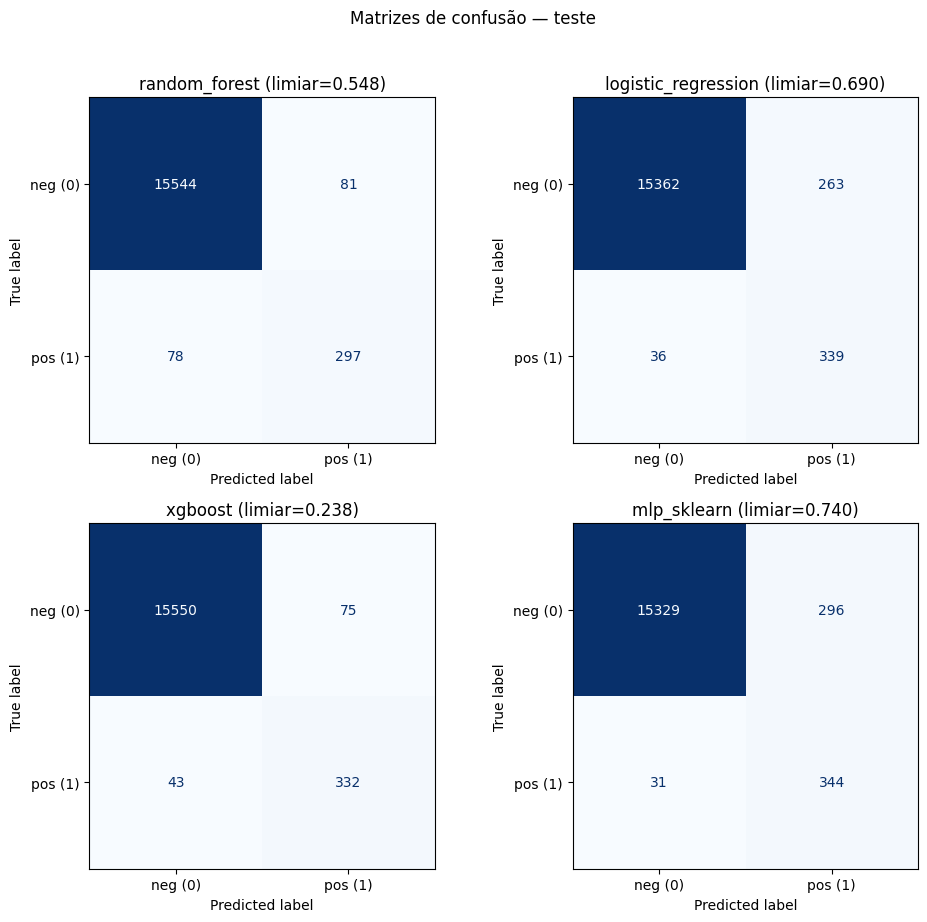

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, name in zip(axes.ravel(), model_names):
    t = thresholds[name]
    y_pred_te = (proba_test(name) >= t).astype(np.int32)
    cm = confusion_matrix(y_test, y_pred_te, labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["neg (0)", "pos (1)"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} (limiar={t:.3f})")
fig.suptitle("Matrizes de confusão — teste", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

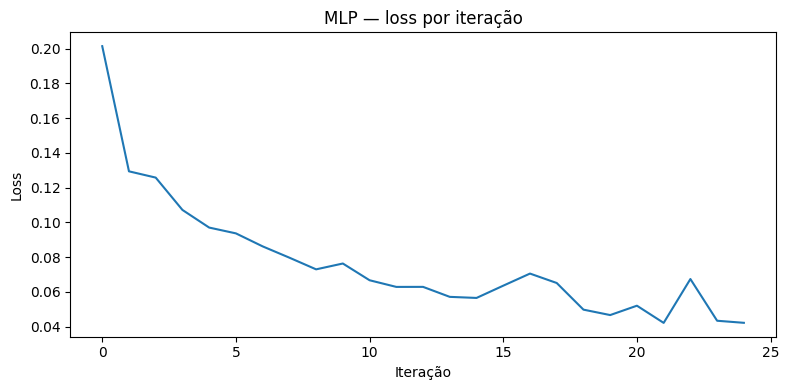

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.loss_curve_)
ax.set_xlabel("Iteração")
ax.set_ylabel("Loss")
ax.set_title("MLP — loss por iteração")
fig.tight_layout()
plt.show()

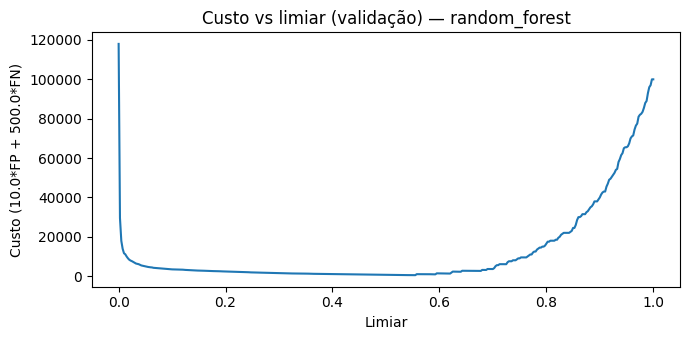

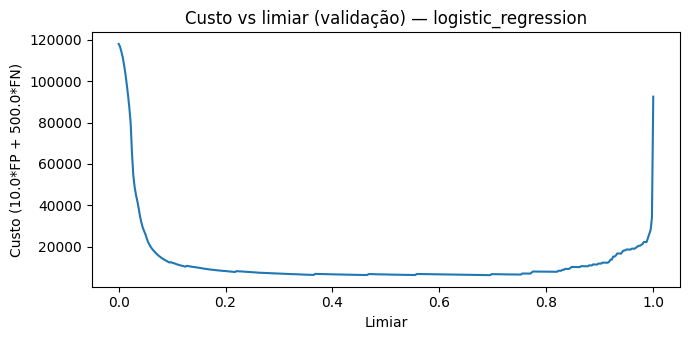

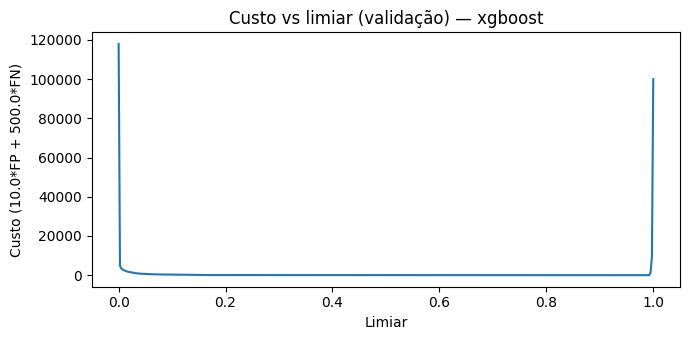

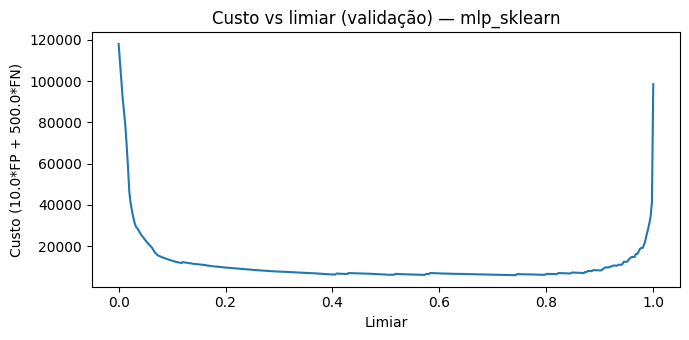

In [38]:
for name in model_names:
    if name == "mlp_sklearn":
        p_val = mlp.predict_proba(X_val_scaled)[:, 1]
    elif name == "random_forest":
        p_val = rf.predict_proba(X_val)[:, 1]
    elif name == "logistic_regression":
        p_val = lr_pipe.predict_proba(X_val)[:, 1]
    else:
        p_val = xgb_final.predict_proba(X_val)[:, 1]
    ts = np.linspace(0, 1, 401)
    costs = [total_cost(y_val, (p_val >= t).astype(np.int32)) for t in ts]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(ts, costs)
    ax.set_xlabel("Limiar")
    ax.set_ylabel(f"Custo ({FP_COST}*FP + {FN_COST}*FN)")
    ax.set_title(f"Custo vs limiar (validação) — {name}")
    fig.tight_layout()
    plt.show()

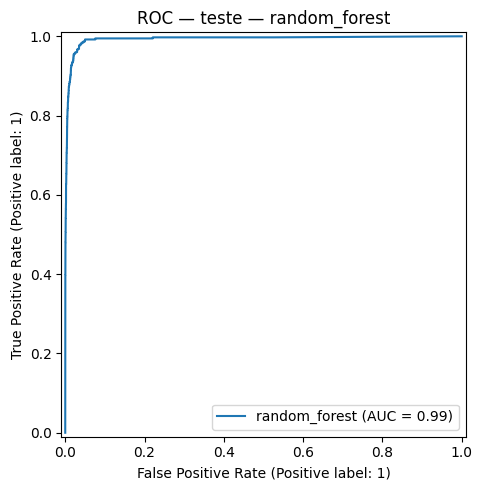

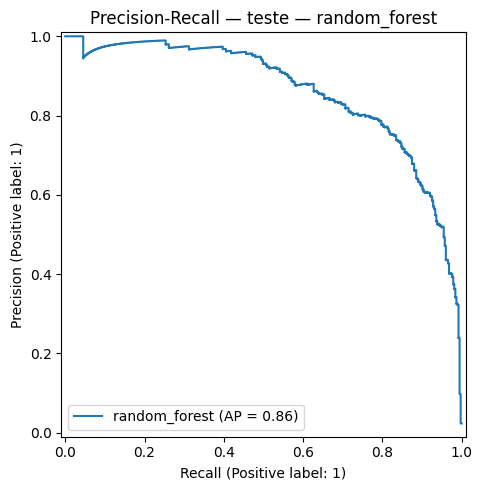

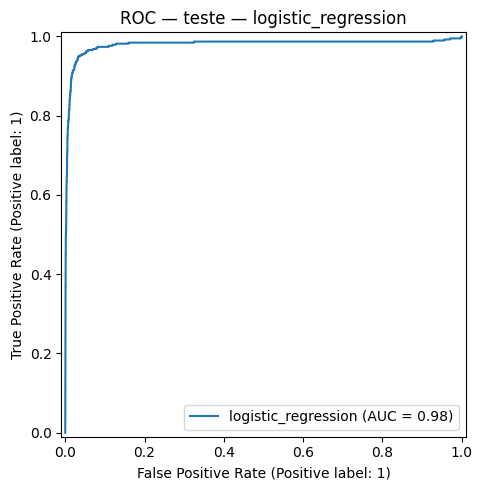

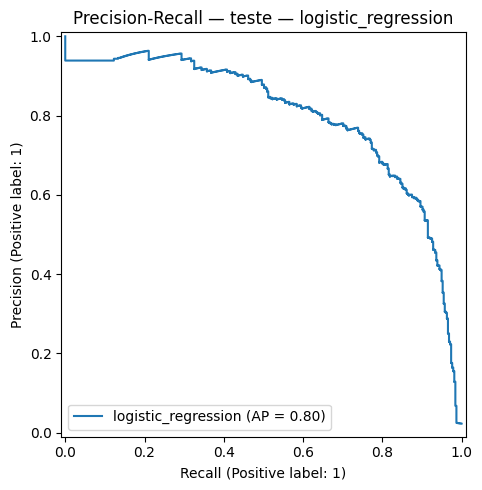

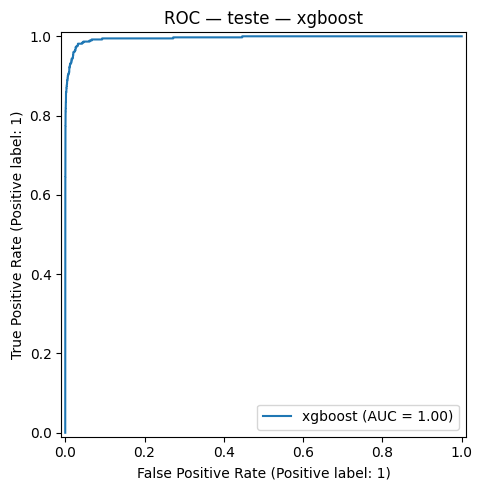

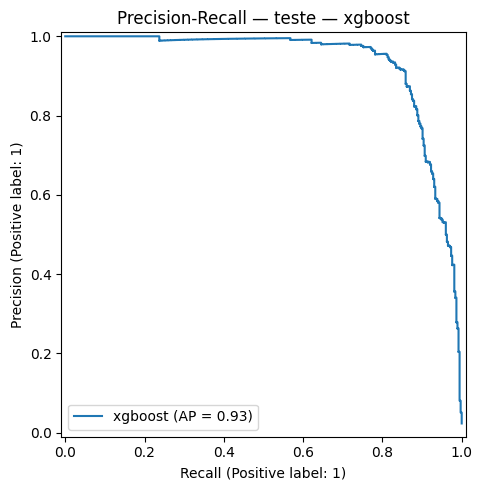

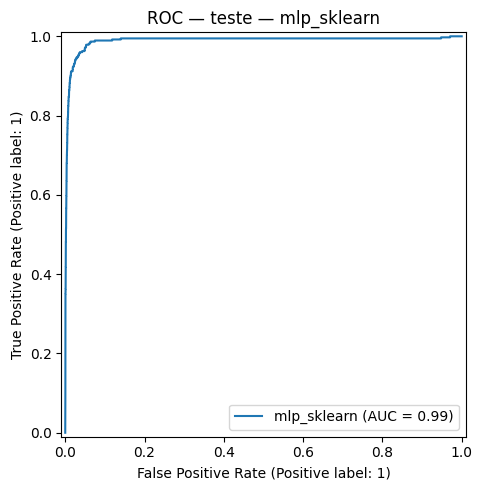

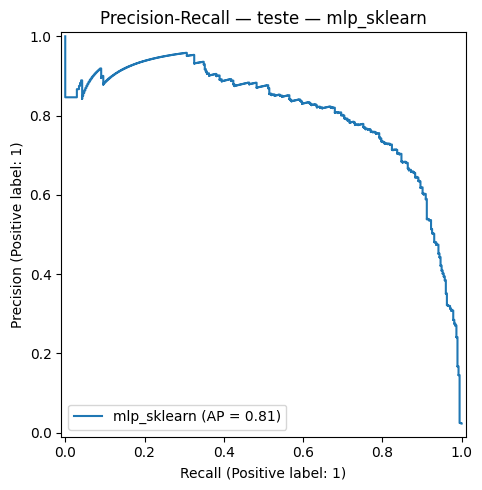

In [39]:
for name in model_names:
    pt = proba_test(name)
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, pt, ax=ax, name=name)
    ax.set_title(f"ROC — teste — {name}")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, pt, ax=ax, name=name)
    ax.set_title(f"Precision-Recall — teste — {name}")
    fig.tight_layout()
    plt.show()


## 6. Grelha de hiperparâmetros — XGBoost (apenas validação)

Não usa o conjunto de teste. Ajuste `param_grid` em `fixed` conforme necessário; mais combinações = mais tempo.

In [40]:
fixed_xgb = {
    "n_estimators_max": min(400, cfg.xgb_n_estimators_max),
    "early_stopping_rounds": cfg.xgb_early_stopping_rounds,
    "max_depth": cfg.xgb_max_depth,
    "learning_rate": cfg.xgb_learning_rate,
    "subsample": cfg.xgb_subsample,
    "colsample_bytree": cfg.xgb_colsample_bytree,
    "min_child_weight": cfg.xgb_min_child_weight,
}
param_grid_xgb = {
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6],
}

df_grid_xgb = grid_search_xgboost_validation(
    X_tr,
    y_tr,
    X_val,
    y_val,
    scale_pos_weight,
    param_grid_xgb,
    fixed_xgb,
    cfg.fp_cost,
    cfg.fn_cost,
    cfg.random_state,
)
display(df_grid_xgb.sort_values("val_cost"))
df_grid_xgb.to_csv(OUTPUT_DIR / "grid_xgb_validation.csv", index=False)

,learning_rate,max_depth,val_threshold,val_cost,best_iteration,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
3,0.05,6,0.014,5890.0,398,0.967250,0.335043,0.980,0.499363,0.993404,0.905853
0,0.03,4,0.260,6010.0,398,0.970333,0.357143,0.975,0.522788,0.994235,0.848910
1,0.03,6,0.050,6070.0,396,0.969833,0.353261,0.975,0.518617,0.994593,0.894256
2,0.05,4,0.092,6330.0,399,0.967667,0.337370,0.975,0.501285,0.994514,0.878628


## 7. (Opcional) Usar módulos `src/` em vez de código inline

Se preferir manter uma única fonte de verdade, adicione a raiz ao `sys.path` e importe:

In [41]:
# import sys
# sys.path.insert(0, str(ROOT))
# from src import data, metrics  # noqa: F401
# Depois chame data.load_raw, metrics.find_best_threshold, etc.

## 8. Dashboard de histórico de execuções

Esta célula resume rapidamente o histórico (`outputs/experiments_log.csv`) e as métricas da execução atual, com tabelas e gráficos.

Execute após rodar o notebook completo.

In [42]:
from pathlib import Path
print("CWD:", Path.cwd().resolve())
print("ROOT:", ROOT.resolve() if "ROOT" in globals() else "ROOT não definido")
print("Dashboard procura:", (Path("outputs") / "experiments_log.csv").resolve())
print("Arquivo correto:", (ROOT / "outputs" / "experiments_log.csv").resolve() if "ROOT" in globals() else "n/a")
print("Existe no caminho do dashboard?", (Path("outputs") / "experiments_log.csv").exists())
print("Existe no caminho correto?", (ROOT / "outputs" / "experiments_log.csv").exists() if "ROOT" in globals() else "n/a")

CWD: C:\Projetos Programação\Cursor\deep_learning_atividade_01 - Copia - Copia\notebooks
ROOT: C:\Projetos Programação\Cursor\deep_learning_atividade_01 - Copia - Copia
Dashboard procura: C:\Projetos Programação\Cursor\deep_learning_atividade_01 - Copia - Copia\notebooks\outputs\experiments_log.csv
Arquivo correto: C:\Projetos Programação\Cursor\deep_learning_atividade_01 - Copia - Copia\outputs\experiments_log.csv
Existe no caminho do dashboard? False
Existe no caminho correto? True


=== Dashboard de Execuções ===
OUT = C:\Projetos Programação\Cursor\deep_learning_atividade_01 - Copia - Copia\outputs

Histórico (últimas execuções):


,timestamp,run_id,best_model_test,best_cost_test,best_recall_test
0,2026-04-08 23:25:53.443047+00:00,fd24325f,mlp_sklearn,18460.0,0.917333
1,2026-04-09 13:18:00.608733+00:00,c0f99fea,mlp_sklearn,18460.0,0.917333
2,2026-04-09 14:43:45.544733+00:00,920cbec9,mlp_sklearn,18460.0,0.917333
3,2026-04-09 16:21:59.227793+00:00,ae5219bb,mlp_sklearn,18460.0,0.917333
4,2026-04-09 16:49:15.222124+00:00,0c17189e,mlp_sklearn,18460.0,0.917333
5,2026-04-09 17:12:04.391488+00:00,e15a708d,mlp_sklearn,18460.0,0.917333


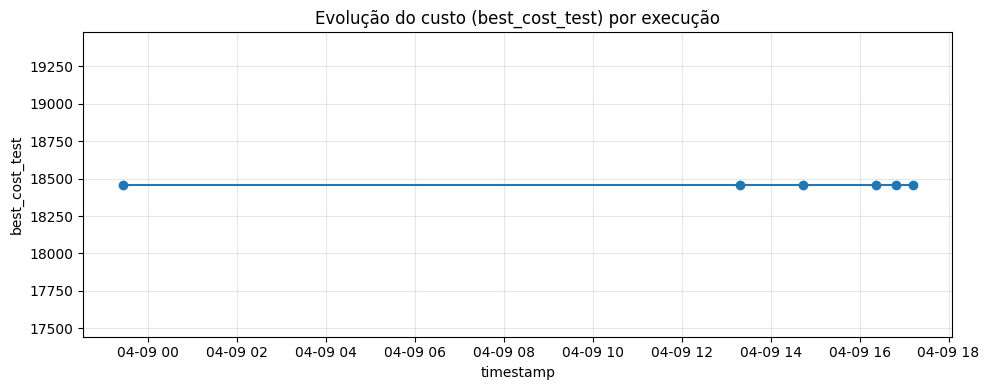

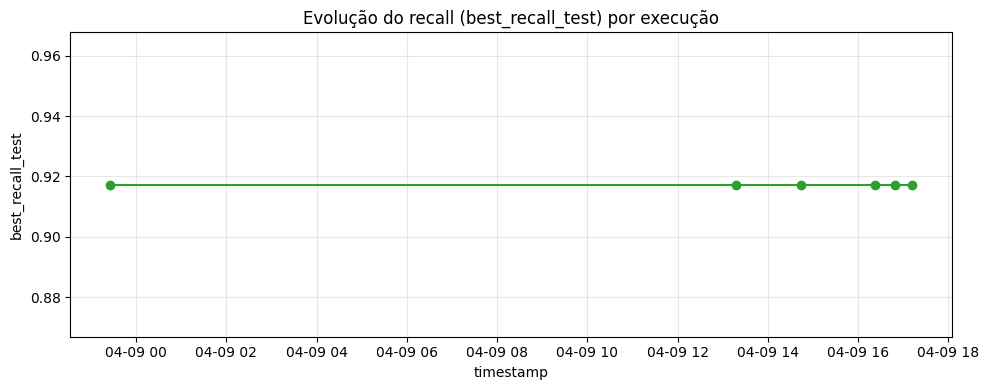

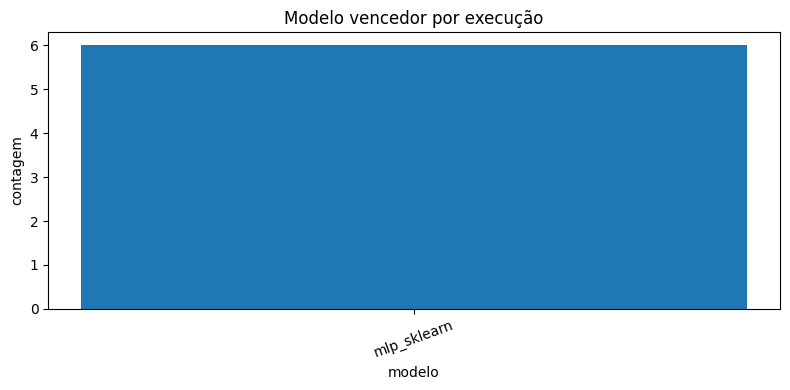


Métricas no teste (run atual, ordenado por custo e recall):


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,cost,true_negatives,false_positives,false_negatives,true_positives
0,mlp_sklearn,0.740,0.979563,0.537500,0.917333,0.677833,0.988815,0.807336,18460.0,15329,296,31,344
1,logistic_regression,0.690,0.981313,0.563123,0.904000,0.693961,0.979459,0.799591,20630.0,15362,263,36,339
2,xgboost,0.238,0.992625,0.815725,0.885333,0.849105,0.995473,0.933720,22250.0,15550,75,43,332
3,random_forest,0.548,0.990062,0.785714,0.792000,0.788845,0.993112,0.861810,39810.0,15544,81,78,297



Métricas no treino (run atual):


,accuracy,precision,recall,f1,roc_auc,pr_auc,cost,threshold,model,true_negatives,false_positives,false_negatives,true_positives,split
0,0.996783,0.838791,0.999,0.911912,0.999818,0.989414,2420.0,0.548,random_forest,58808,192,1,999,train
1,0.982150,0.481860,0.943,0.637809,0.991473,0.789429,38640.0,0.690,logistic_regression,57986,1014,57,943,train
2,0.999883,0.993049,1.000,0.996512,1.000000,1.000000,70.0,0.238,xgboost,58993,7,0,1000,train
3,0.980867,0.463761,0.947,0.622617,0.992685,0.815246,37450.0,0.740,mlp_sklearn,57905,1095,53,947,train


In [43]:
# Dashboard rápido: histórico + resultados da execução atual
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Usa o mesmo diretório de saída definido no notebook, independente do CWD do kernel.
OUT = OUTPUT_DIR
log_path = OUT / "experiments_log.csv"
metrics_test_path = OUT / "metrics_test.csv"
metrics_train_path = OUT / "metrics_train.csv"

print("=== Dashboard de Execuções ===")
print("OUT =", OUT.resolve())

if log_path.exists():
    df_log = pd.read_csv(log_path)
    if not df_log.empty:
        if "timestamp" in df_log.columns:
            df_log["timestamp"] = pd.to_datetime(df_log["timestamp"], errors="coerce", utc=True)
            df_log = df_log.sort_values("timestamp")

        cols = [c for c in ["timestamp", "run_id", "best_model_test", "best_cost_test", "best_recall_test"] if c in df_log.columns]
        print("\nHistórico (últimas execuções):")
        display(df_log[cols].tail(15) if cols else df_log.tail(15))

        if "best_cost_test" in df_log.columns and "timestamp" in df_log.columns:
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(df_log["timestamp"], df_log["best_cost_test"], marker="o")
            ax.set_title("Evolução do custo (best_cost_test) por execução")
            ax.set_xlabel("timestamp")
            ax.set_ylabel("best_cost_test")
            ax.grid(True, alpha=0.3)
            fig.tight_layout()
            plt.show()

        if "best_recall_test" in df_log.columns and "timestamp" in df_log.columns:
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(df_log["timestamp"], df_log["best_recall_test"], marker="o", color="tab:green")
            ax.set_title("Evolução do recall (best_recall_test) por execução")
            ax.set_xlabel("timestamp")
            ax.set_ylabel("best_recall_test")
            ax.grid(True, alpha=0.3)
            fig.tight_layout()
            plt.show()

        if "best_model_test" in df_log.columns:
            fig, ax = plt.subplots(figsize=(8, 4))
            model_counts = df_log["best_model_test"].value_counts(dropna=False)
            ax.bar(model_counts.index.astype(str), model_counts.values)
            ax.set_title("Modelo vencedor por execução")
            ax.set_xlabel("modelo")
            ax.set_ylabel("contagem")
            ax.tick_params(axis="x", rotation=20)
            fig.tight_layout()
            plt.show()
    else:
        print("experiments_log.csv existe, mas está vazio.")
else:
    print("Ainda não existe outputs/experiments_log.csv. Rode as células de treino e avaliação primeiro.")

if metrics_test_path.exists():
    df_test = pd.read_csv(metrics_test_path)
    print("\nMétricas no teste (run atual, ordenado por custo e recall):")
    if {"cost", "recall"}.issubset(df_test.columns):
        display(df_test.sort_values(["cost", "recall"], ascending=[True, False]))
    else:
        display(df_test)

if metrics_train_path.exists():
    df_train = pd.read_csv(metrics_train_path)
    print("\nMétricas no treino (run atual):")
    display(df_train)
